In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb

from sklearn.metrics import r2_score, mean_absolute_error

import joblib
import matplotlib.pyplot as plt

In [2]:
# 2. Load Dataset
# ==============================
df = pd.read_csv("../dataset/house_price_50k.csv")

# ==============================
# 3. Overview
# ==============================
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [3]:
df = df.dropna()

le_location = LabelEncoder()
le_income = LabelEncoder()

df['location'] = le_location.fit_transform(df['location'])
df['income_level'] = le_income.fit_transform(df['income_level'])

In [4]:
# ==============================
# 5. Feature Engineering
# ==============================
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['luxury'] = df['garage'] + df['garden'] + df['security']

In [5]:
# ==============================
# 6. Split Data
# ==============================
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# ==============================
# 8. Models
# ==============================
models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=200),
    "GradientBoost": GradientBoostingRegressor(),
    "XGBoost": xgb.XGBRegressor()
}


In [7]:
# ==============================
# 9. Train & Evaluate
# ==============================
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    results[name] = r2

    print(f"{name}")
    print("R2:", r2)
    print("MAE:", mae)
    print("-"*30)

Linear
R2: 0.9968488990272465
MAE: 20692.584282582375
------------------------------
DecisionTree
R2: 0.9913250647566991
MAE: 33815.01452111458
------------------------------
RandomForest
R2: 0.996646245669918
MAE: 21281.825606492555
------------------------------
GradientBoost
R2: 0.9972989266695946
MAE: 18996.879752970588
------------------------------
XGBoost
R2: 0.9974332769366046
MAE: 18596.854060158697
------------------------------


In [8]:
# ==============================
# 10. Best Model
# ==============================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)


Best Model: XGBoost


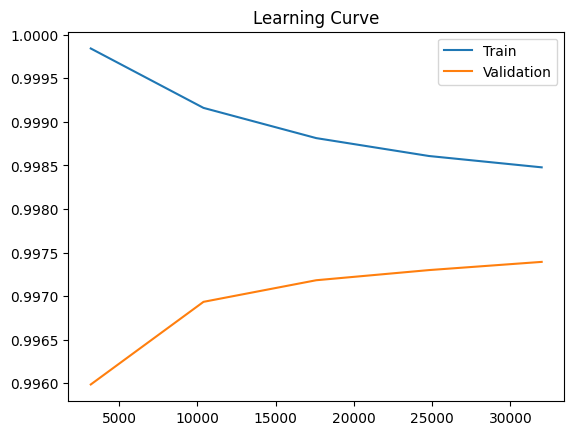

In [9]:
# ==============================
# 11. Learning Curve
# ==============================
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='r2'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [10]:
# ==============================
# 12. Feature Importance
# ==============================
if hasattr(best_model, "feature_importances_"):
    for i, v in enumerate(best_model.feature_importances_):
        print(X.columns[i], ":", v)

area : 0.95132095
bedrooms : 0.0020223488
bathrooms : 0.00014437726
floors : 0.00082740496
age : 0.005502533
distance : 0.0024735096
garage : 0.00018177365
parking : 0.0005074914
garden : 0.00017563441
security : 0.00015116399
school_nearby : 0.00013286826
hospital_nearby : 0.00013507142
shopping_mall_nearby : 0.00013557858
public_transport : 0.00011189991
crime_rate : 0.0007347898
population_density : 0.0004074189
location : 0.018517712
income_level : 0.00896704
total_rooms : 0.006766215
luxury : 0.00078414223


In [11]:
# ==============================
# 13. Save Model
# ==============================
joblib.dump(best_model, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le_location, "../models/location_encoder.pkl")
joblib.dump(le_income, "../models/income_encoder.pkl")

['../models/income_encoder.pkl']